In [70]:
from typing import TypedDict

import os
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END

from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_community.tools.tavily_search import TavilySearchResults

from IPython.display import Markdown, display
from langchain.chat_models import init_chat_model
load_dotenv()

True

In [71]:
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

initialize gemini

In [84]:
# llm = ChatGoogleGenerativeAI(
#     model="gemini-3-flash-preview",
#     temperature=0.2
# )

llm=init_chat_model("groq:llama-3.3-70b-versatile")

Initialize Tavily

In [85]:
search_tool = TavilySearchResults(
    max_results=5,
    search_depth="advanced"
)

define the state

In [86]:
from typing import TypedDict, List, Dict, Any


class GeneralAgentState(TypedDict):
    question: str

    search_results: List[Dict[str, Any]]

    evidence: str

    answer: str

    formatted_response: str

input validation node

In [87]:
def input_validation_node(state: GeneralAgentState):

    question = state["question"].strip()

    if not question:
        raise ValueError("Question cannot be empty.")

    state["question"] = question

    print("Input Validation Passed")

    return state

test the node

In [88]:
test_state = {
    "question": "   What is drip irrigation?   "
}

result = input_validation_node(test_state)

print(result)

Input Validation Passed
{'question': 'What is drip irrigation?'}


info retrival node


In [89]:
def information_retrieval_node(state: GeneralAgentState):

    question = state["question"]

    print(f"Searching for: {question}")

    results = search_tool.invoke(question)

    state["search_results"] = results

    print(f"Retrieved {len(results)} search results")

    return state

test the node

In [90]:
state = {
    "question": "How to improve soil fertility?"
}

state = input_validation_node(state)

state = information_retrieval_node(state)

print(state["search_results"])

Input Validation Passed
Searching for: How to improve soil fertility?


Retrieved 5 search results
[{'title': 'Ask a Gardener: How Do I Improve My Soil Without Fertilizer? - Brooklyn Botanic Garden', 'url': 'https://www.bbg.org/article/how_do_i_improve_my_soil_without_chemical_fertilizer', 'content': 'Whether your gardening space is new or established, a great way to improve soil fertility is to add compost. If you are working in a new space, you can mix the compost into the soil, but if you have an established garden and don’t want to disturb the soil, you can just spread a layer on top. (This is called “top dressing.”) The organisms that live in your soil will move the compost around over time. [...] Compost can do so much for your garden, including giving your plants a boost of nutrition, improving your soil structure, and improving the microbial activity in your soil. (Composted manure, though sometimes harder to come by, is another option that serves the same purpose.) Top dress in the spring or fall when plants are actively growing. A quarter or a ha

In [91]:
import json
print(json.dumps(state["search_results"], indent=2))

[
  {
    "title": "Ask a Gardener: How Do I Improve My Soil Without Fertilizer? - Brooklyn Botanic Garden",
    "url": "https://www.bbg.org/article/how_do_i_improve_my_soil_without_chemical_fertilizer",
    "content": "Whether your gardening space is new or established, a great way to improve soil fertility is to add compost. If you are working in a new space, you can mix the compost into the soil, but if you have an established garden and don\u2019t want to disturb the soil, you can just spread a layer on top. (This is called \u201ctop dressing.\u201d) The organisms that live in your soil will move the compost around over time. [...] Compost can do so much for your garden, including giving your plants a boost of nutrition, improving your soil structure, and improving the microbial activity in your soil. (Composted manure, though sometimes harder to come by, is another option that serves the same purpose.) Top dress in the spring or fall when plants are actively growing. A quarter or 

evidence processing node

In [92]:
def evidence_processing_node(state: GeneralAgentState):

    search_results = state["search_results"]

    evidence_blocks = []

    for idx, result in enumerate(search_results, start=1):

        title = result.get("title", "Unknown Source")
        content = result.get("content", "")
        url = result.get("url", "")

        block = f"""
Source {idx}
Title: {title}

Content:
{content}

Reference:
{url}
"""

        evidence_blocks.append(block.strip())

    state["evidence"] = "\n\n" + "=" * 80 + "\n\n".join(evidence_blocks)

    print(f"Processed {len(search_results)} evidence sources")

    return state

In [93]:
state = evidence_processing_node(state)

print(state["evidence"][:3000])

Processed 5 evidence sources


================================================================================Source 1
Title: Ask a Gardener: How Do I Improve My Soil Without Fertilizer? - Brooklyn Botanic Garden

Content:
Whether your gardening space is new or established, a great way to improve soil fertility is to add compost. If you are working in a new space, you can mix the compost into the soil, but if you have an established garden and don’t want to disturb the soil, you can just spread a layer on top. (This is called “top dressing.”) The organisms that live in your soil will move the compost around over time. [...] Compost can do so much for your garden, including giving your plants a boost of nutrition, improving your soil structure, and improving the microbial activity in your soil. (Composted manure, though sometimes harder to come by, is another option that serves the same purpose.) Top dress in the spring or fall when plants are actively growing. A quarter or a half-inch

agricultural reasoning node

In [94]:
from langchain_core.messages import HumanMessage


def agricultural_reasoning_node(state: GeneralAgentState):

    question = state["question"]
    evidence = state["evidence"]

    prompt = f"""
You are an expert agricultural advisor.

Your task is to answer the user's question using ONLY the provided evidence.

Instructions:

1. Read all the evidence carefully.
2. Combine information from multiple sources when appropriate.
3. Do not invent facts.
4. If the evidence is insufficient, clearly state that.
5. Explain the answer in simple language suitable for farmers.
6. Organize the response using markdown headings and bullet points where appropriate.
7. Do not mention that you are an AI or that you were given evidence.

User Question:
{question}

Evidence:
{evidence}
"""

    response = llm.invoke(
        [HumanMessage(content=prompt)]
    )

    state["answer"] = response.content

    print("Agricultural reasoning completed.")

    return state

In [95]:
state = agricultural_reasoning_node(state)

print(state["answer"])

Agricultural reasoning completed.
### Introduction to Improving Soil Fertility
Improving soil fertility is crucial for a healthy and productive garden. It involves adding nutrients and organic matter to the soil to enhance its structure, support microbial activity, and promote plant growth.

### Methods to Improve Soil Fertility
Several methods can be used to improve soil fertility, including:
* **Adding Compost**: Compost can be mixed into the soil or used as a top dressing. It provides nutrients, improves soil structure, and supports microbial activity.
* **Mulching**: Mulching involves applying a layer of organic material, such as dried leaves or dead plants, to the soil surface. As it decomposes, it adds nutrients and feeds the soil microbiome.
* **Cover Cropping**: Planting cover crops, such as winter rye or crimson clover, during the off-season can help improve soil fertility. These crops are not harvested but are instead tilled into the soil or cut down and left as mulch.
* **Ad

In [98]:
GENERAL_REASONING_PROMPT = """
You are an expert agricultural advisor.

Your task is to answer the user's question using ONLY the provided evidence.

Instructions:

1. Read all the evidence carefully.
2. Combine information from multiple sources.
3. Do not invent facts.
4. If the evidence is insufficient, clearly say so.
5. Explain the answer in simple language suitable for farmers.
6. Use markdown headings and bullet points.
7. Do not mention the evidence or that you are an AI.

User Question:
{question}

Evidence:
{evidence}
"""

agricultural reasoning node

In [100]:
from langchain_core.messages import HumanMessage

def agricultural_reasoning_node(state: GeneralAgentState):

    # Extract data from the state
    question = state["question"]
    evidence = state["evidence"]

    # Build the prompt
    prompt = GENERAL_REASONING_PROMPT.format(
        question=question,
        evidence=evidence
    )

    print("Generating response with Gemini...")

    # Invoke Gemini
    response = llm.invoke(
        [HumanMessage(content=prompt)]
    )

    # Store the generated answer
    state["answer"] = response.content

    print("Agricultural reasoning completed.")

    return state

In [101]:
from IPython.display import Markdown, display

display(Markdown(state["answer"]))

### Introduction to Improving Soil Fertility
Improving soil fertility is crucial for a healthy and productive garden. It involves adding nutrients and organic matter to the soil to enhance its structure, support microbial activity, and promote plant growth.

### Methods to Improve Soil Fertility
Several methods can be used to improve soil fertility, including:
* **Adding Compost**: Compost can be mixed into the soil or used as a top dressing. It provides nutrients, improves soil structure, and supports microbial activity.
* **Mulching**: Mulching involves applying a layer of organic material, such as dried leaves or dead plants, to the soil surface. As it decomposes, it adds nutrients and feeds the soil microbiome.
* **Cover Cropping**: Planting cover crops, such as winter rye or crimson clover, during the off-season can help improve soil fertility. These crops are not harvested but are instead tilled into the soil or cut down and left as mulch.
* **Adding Organic Matter**: Adding organic matter, such as well-composted horse manure, shredded leaves, or grass clippings, can improve soil fertility and structure.
* **Using Natural Fertilizers**: Natural fertilizers, such as lime and gypsum, can be used to moderate soil pH and deliver essential calcium and sulfur.

### Tips for Improving Soil Fertility
Some additional tips for improving soil fertility include:
* **Avoid Over-Tilling**: Over-tilling can damage soil structure and kill beneficial microorganisms. Instead, apply compost or mulch to the soil surface.
* **Use a Mulching Mower**: Using a mulching mower to return grass clippings to the soil can help add organic matter and nutrients.
* **Apply Compost Regularly**: Applying compost regularly, such as twice a year, can help maintain soil fertility and structure.
* **Test Your Soil**: Testing your soil can help identify nutrient deficiencies and imbalances, allowing you to make informed decisions about fertilization and soil management.

### Conclusion
Improving soil fertility is a crucial step in creating a healthy and productive garden. By using a combination of methods, such as adding compost, mulching, and cover cropping, and following tips like avoiding over-tilling and applying compost regularly, you can enhance your soil's fertility and support the growth of strong, healthy plants.

In [102]:
from typing import TypedDict, List, Dict, Any

class GeneralAgentState(TypedDict):
    question: str
    search_results: List[Dict[str, Any]]
    evidence: str
    answer: str
    formatted_response: Dict[str, Any]

response formatter node

In [103]:
def response_formatter_node(state: GeneralAgentState):

    sources = []

    for result in state["search_results"]:

        sources.append({
            "title": result.get("title", ""),
            "url": result.get("url", "")
        })

    state["formatted_response"] = {

        "agent": "general_agriculture",

        "question": state["question"],

        "answer": state["answer"],

        "sources": sources

    }

    print("Response formatted successfully.")

    return state

test the node

In [104]:
state = response_formatter_node(state)

state["formatted_response"]

Response formatted successfully.


{'agent': 'general_agriculture',
 'question': 'How to improve soil fertility?',
 'answer': "### Introduction to Improving Soil Fertility\nImproving soil fertility is crucial for a healthy and productive garden. It involves adding nutrients and organic matter to the soil to enhance its structure, support microbial activity, and promote plant growth.\n\n### Methods to Improve Soil Fertility\nSeveral methods can be used to improve soil fertility, including:\n* **Adding Compost**: Compost can be mixed into the soil or used as a top dressing. It provides nutrients, improves soil structure, and supports microbial activity.\n* **Mulching**: Mulching involves applying a layer of organic material, such as dried leaves or dead plants, to the soil surface. As it decomposes, it adds nutrients and feeds the soil microbiome.\n* **Cover Cropping**: Planting cover crops, such as winter rye or crimson clover, during the off-season can help improve soil fertility. These crops are not harvested but are i

build the langgraph

In [105]:
from langgraph.graph import StateGraph, START, END

# Create the graph
builder = StateGraph(GeneralAgentState)

# Add nodes
builder.add_node("input_validation", input_validation_node)

builder.add_node("information_retrieval", information_retrieval_node)

builder.add_node("evidence_processing", evidence_processing_node)

builder.add_node("agricultural_reasoning", agricultural_reasoning_node)

builder.add_node("response_formatter", response_formatter_node)

connect the nodes

In [106]:
# START → Input Validation
builder.add_edge(START, "input_validation")

# Input Validation → Information Retrieval
builder.add_edge(
    "input_validation",
    "information_retrieval"
)

# Information Retrieval → Evidence Processing
builder.add_edge(
    "information_retrieval",
    "evidence_processing"
)

# Evidence Processing → Agricultural Reasoning
builder.add_edge(
    "evidence_processing",
    "agricultural_reasoning"
)

# Agricultural Reasoning → Response Formatter
builder.add_edge(
    "agricultural_reasoning",
    "response_formatter"
)

# Response Formatter → END
builder.add_edge(
    "response_formatter",
    END
)

compile the graph

In [107]:
general_agri_graph = builder.compile()

visualize the graph

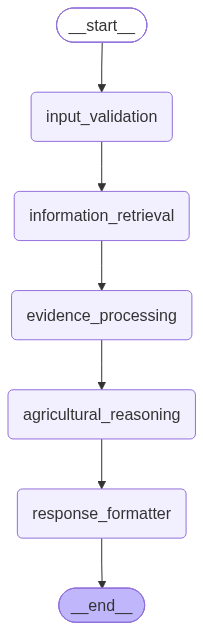

In [108]:
from IPython.display import Image, display

display(
    Image(
        general_agri_graph.get_graph().draw_mermaid_png()
    )
)

test the entire graph

In [109]:
result = general_agri_graph.invoke(
    {
        "question": "How can I naturally improve soil fertility?"
    }
)

Input Validation Passed
Searching for: How can I naturally improve soil fertility?
Retrieved 5 search results
Processed 5 evidence sources
Generating response with Gemini...
Agricultural reasoning completed.
Response formatted successfully.


display the final response

In [110]:
from IPython.display import Markdown, display

display(
    Markdown(result["formatted_response"]["answer"])
)

### Introduction to Improving Soil Fertility
Improving soil fertility is crucial for maintaining a healthy garden. Fortunately, there are several natural methods to achieve this without using chemical fertilizers.

### Natural Methods to Improve Soil Fertility
The following are some natural ways to improve soil fertility:
* **Add Compost**: Compost can be mixed into the soil or used as a top dressing. It provides nutrients, improves soil structure, and increases microbial activity.
* **Mulch the Soil Surface**: Mulching improves soil quality, protects plants from heat and cold, and prevents weed growth. Organic materials like grass, leaves, and hay can be used to create mulch.
* **Use Aged Manure**: Aged manure from animals like bats, horses, sheep, cows, goats, chickens, and rabbits is rich in nutrients and improves soil structure.
* **Grow Cover Crops**: Cover crops prevent erosion, inhibit weed growth, and reduce soil compaction. They can be planted at the end of the gardening season and left for the winter.
* **Add Organic Matter**: Sources of organic matter should be diverse and can include materials like potatoes, grass clippings, and leaf waste.
* **Prevent Soil Compaction**: Avoid activities that compact the soil, making it difficult for plants to absorb water and nutrients.
* **Use Crop Rotation**: Rotate crops to prevent soil pathogens from building up and to increase soil fertility.
* **Use Lime and Gypsum**: Naturally mined lime and gypsum can moderate soil pH and deliver essential calcium.
* **Use Plant and Seaweed Products**: Alfalfa meal, pellets, and leaf and plant-waste compost can be used as natural fertilizers.

### Benefits of Improving Soil Fertility
Improving soil fertility has several benefits, including:
* Increasing the water-holding capacity of the soil
* Reducing erosion
* Decreasing the loss of valuable minerals by leaching
* Making the soil easier to cultivate
* Providing a more favorable soil structure for plant growth

### Conclusion
Improving soil fertility is essential for maintaining a healthy and productive garden. By using natural methods like adding compost, mulching, and using aged manure, you can create a fertile soil that supports plant growth and reduces the need for chemical fertilizers.

show sources

In [111]:
for source in result["formatted_response"]["sources"]:
    print(f"- {source['title']}")
    print(f"  {source['url']}\n")

- Ask a Gardener: How Do I Improve My Soil Without Fertilizer?
  https://www.bbg.org/article/how_do_i_improve_my_soil_without_chemical_fertilizer

- Discover 10 Simple and Natural Ways to Improve Soil Quality in Your Ga
  https://plantrevolution.com/blogs/news/ways-improve-soil-quality-garden

- How To Make Soil Fertile Naturally – Mother Earth News
  https://www.motherearthnews.com/organic-gardening/8-steps-to-make-better-garden-soil-zmaz07jjzsel

- 20 Ways to Boost Soil Fertility
  https://rodaleinstitute.org/blog/20-ways-to-boost-soil-fertility

- Improving Garden Soil Fertility
  https://extension.okstate.edu/fact-sheets/improving-garden-soil-fertility



testing with good questioms

In [112]:
result = general_agri_graph.invoke(
    {
        "question": "My soil has low fertility and water is scarce. What farming practices should I adopt?"
    }
)

from IPython.display import Markdown, display

display(Markdown(result["formatted_response"]["answer"]))

Input Validation Passed
Searching for: My soil has low fertility and water is scarce. What farming practices should I adopt?
Retrieved 5 search results
Processed 5 evidence sources
Generating response with Gemini...
Agricultural reasoning completed.
Response formatted successfully.


### Introduction to Drought-Resistant Farming Practices
To address the issues of low soil fertility and water scarcity, several farming practices can be adopted. These practices focus on improving soil health, reducing water loss, and promoting efficient water use.

### Soil Health Practices
To improve soil fertility and water-holding capacity, consider the following:
* **Reduce or eliminate tillage**: This helps preserve soil structure and retain water.
* **Add organic amendments**: Incorporate materials like manure, compost, or biochar to improve soil health and water retention.
* **Use cover crops**: Plant cover crops to reduce soil erosion, increase water retention, and improve soil biodiversity.
* **Increase soil organic matter**: Add crop residues, compost, or manure to build soil structure and retain water.

### Water Conservation Practices
To optimize water use, consider the following:
* **Implement conservation tillage**: Reduce tillage to minimize water loss and retain soil moisture.
* **Use efficient irrigation systems**: Upgrade to drip or micro-irrigation systems to reduce water waste.
* **Monitor soil moisture**: Regularly check soil moisture levels to irrigate accordingly.
* **Store water**: Build water storage systems, such as ponds or tanks, to collect and conserve water.

### Crop Selection and Management
To make the most of available water, consider the following:
* **Choose drought-tolerant crops**: Select crop species and varieties that can withstand dry conditions, such as melons, tomatoes, and squash.
* **Optimize crop watering**: Water crops at the most appropriate intervals for their specific needs.
* **Control weeds**: Regularly remove weeds to reduce competition for water and nutrients.

### Additional Recommendations
* **Rotate crops and grazing**: Implement rotational grazing and crop rotation to improve soil health and reduce water stress.
* **Use mulching and residue management**: Retain crop residues and use mulch to reduce water loss and retain soil moisture.
* **Regularly test soil**: Monitor soil fertility and adjust management strategies accordingly to optimize nutrient use and reduce waste.

In [ ]:
# getting the sources from the formatted response and printing them in a readable format
for source in result["formatted_response"]["sources"]:
    print(f"• {source['title']}")
    print(f"  {source['url']}\n")

• 7 field-proven ways to mitigate drought on your farm
  https://www.farmprogress.com/soil-health/7-field-proven-ways-to-mitigate-drought-on-your-farm

• 15 Ways to Help Mitigate Drought on Your Farm This Season and Beyond | College of Agricultural Sciences
  https://smallfarms.oregonstate.edu/smallfarms/15-ways-help-mitigate-drought-your-farm-season-and-beyond

• How Regenerative Agriculture Can Mitigate Drought
  https://www.nrdc.org/bio/arohi-sharma/how-regenerative-agriculture-can-mitigate-drought

• Making Your Land More Resilient to Drought | Farmers.gov
  https://www.farmers.gov/blog/making-your-land-more-resilient-drought

• Soil Fertility Management
  http://files.extension.wsu.edu/em108-ch6.pdf

